In [1]:
!pip install -q -U watermark

In [1]:
# importando as bibliotecas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
%reload_ext watermark
%watermark -a "Emanoel Souza"

Author: Emanoel Souza



In [3]:
%watermark --iversions

matplotlib: 3.10.0
numpy     : 2.1.2
pandas    : 2.2.3
seaborn   : 0.13.2



In [4]:
#lendo a base de dados com pandas
Base = pd.read_csv('youtube_analytics_dataset.csv')

In [5]:
#transformando a base em um dataframe
table = pd.DataFrame(Base)

In [6]:
table.rename(columns = {'title': 'titulo', 'title_length': 'tamanho_title', 'channel_name': 'nome_canal', 'channel_id': 'canal_id', 'like_per_view': 'like_p_view', 'comment_per_view': 'comentario_p_view', 'engagement_rate': 'taxa_de_engajamento', 'subscriber_tier': 'incrito_categoria'}, inplace = True )

In [7]:
table.head()

,video_id,titulo,tamanho_title,emoji_count_title,nome_canal,canal_id,view_count,duration_seconds,published_text,region,...,comment_count,like_p_view,comentario_p_view,taxa_de_engajamento,days_since_published,has_emoji,title_char_per_word,video_length_category,subscriber_count,incrito_categoria
0,video_0,Video Title 0,71,1,Channel_246,UC878781,1002,60,15 days ago,KR,...,14,0.095808,0.013972,0.109780,15,1,17.75,Short (<1m),101,Nano
1,video_1,Video Title 1,34,0,Channel_140,UC609433,1000,1800,1 days ago,IN,...,20,0.117000,0.020000,0.137000,1,0,8.50,Extended (10-30m),100,Nano
2,video_2,Video Title 2,91,1,Channel_808,UC557225,1005,60,2 days ago,DE,...,25,0.012935,0.024876,0.037811,2,1,22.75,Short (<1m),100,Nano
3,video_3,Video Title 3,80,0,Channel_258,UC770773,1001,1800,1 days ago,DE,...,5,0.081918,0.004995,0.086913,1,0,20.00,Extended (10-30m),102,Nano
4,video_4,Video Title 4,40,2,Channel_617,UC271705,1000,300,15 days ago,FR,...,28,0.099000,0.028000,0.127000,15,1,10.00,Medium (1-5m),100,Nano


# Estatística Descritiva no Geral

In [8]:
df = table.astype({x: 'string' for x in table.select_dtypes(include = 'object').columns})

In [9]:
df

,video_id,titulo,tamanho_title,emoji_count_title,nome_canal,canal_id,view_count,duration_seconds,published_text,region,...,comment_count,like_p_view,comentario_p_view,taxa_de_engajamento,days_since_published,has_emoji,title_char_per_word,video_length_category,subscriber_count,incrito_categoria
0,video_0,Video Title 0,71,1,Channel_246,UC878781,1002,60,15 days ago,KR,...,14,0.095808,0.013972,0.109780,15,1,17.75,Short (<1m),101,Nano
1,video_1,Video Title 1,34,0,Channel_140,UC609433,1000,1800,1 days ago,IN,...,20,0.117000,0.020000,0.137000,1,0,8.50,Extended (10-30m),100,Nano
2,video_2,Video Title 2,91,1,Channel_808,UC557225,1005,60,2 days ago,DE,...,25,0.012935,0.024876,0.037811,2,1,22.75,Short (<1m),100,Nano
3,video_3,Video Title 3,80,0,Channel_258,UC770773,1001,1800,1 days ago,DE,...,5,0.081918,0.004995,0.086913,1,0,20.00,Extended (10-30m),102,Nano
4,video_4,Video Title 4,40,2,Channel_617,UC271705,1000,300,15 days ago,FR,...,28,0.099000,0.028000,0.127000,15,1,10.00,Medium (1-5m),100,Nano
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,video_9995,Video Title 9995,26,1,Channel_224,UC733581,1000,3600,13 days ago,IN,...,14,0.118000,0.014000,0.132000,13,1,6.50,Very Long (>30m),100,Nano
9996,video_9996,Video Title 9996,68,0,Channel_737,UC813260,1000,60,17 days ago,US,...,3,0.052000,0.003000,0.055000,17,0,17.00,Short (<1m),100,Nano
9997,video_9997,Video Title 9997,92,0,Channel_637,UC155270,1000,300,6 days ago,CA,...,22,0.109000,0.022000,0.131000,6,0,23.00,Medium (1-5m),100,Nano
9998,video_9998,Video Title 9998,60,0,Channel_660,UC194516,1000,3600,20 days ago,US,...,8,0.133000,0.008000,0.141000,20,0,15.00,Very Long (>30m),111,Nano


# Tratamento da Base

In [10]:
# Feito o tratamento da base, verificação de valores unios, nulos, ou duplicatas

In [11]:
df['video_length_category'].unique

<bound method Series.unique of 0             Short (<1m)
1       Extended (10-30m)
2             Short (<1m)
3       Extended (10-30m)
4           Medium (1-5m)
              ...        
9995     Very Long (>30m)
9996          Short (<1m)
9997        Medium (1-5m)
9998     Very Long (>30m)
9999     Very Long (>30m)
Name: video_length_category, Length: 10000, dtype: string>

In [12]:
df.isnull().any()

video_id                 False
titulo                   False
tamanho_title            False
emoji_count_title        False
nome_canal               False
canal_id                 False
view_count               False
duration_seconds         False
published_text           False
region                   False
category                 False
is_live                  False
scraped_at               False
like_count               False
comment_count            False
like_p_view              False
comentario_p_view        False
taxa_de_engajamento      False
days_since_published     False
has_emoji                False
title_char_per_word      False
video_length_category    False
subscriber_count         False
incrito_categoria        False
dtype: bool

In [13]:
# Exploração dos dados por meio de estatística geral dos elementos

In [14]:
df1=df.groupby('video_length_category')['like_count'].sum().sort_values(ascending=False)
print(df1)

video_length_category
Extended (10-30m)    230268
Medium (1-5m)        227518
Short (<1m)          113399
Long (5-10m)         113177
Very Long (>30m)     107820
Name: like_count, dtype: int64


In [15]:
media_likes_c = df.groupby('video_length_category')['like_count'].mean().sort_values(ascending=True)
print(media_likes_c)

video_length_category
Long (5-10m)         77.624829
Short (<1m)          78.476817
Extended (10-30m)    79.238816
Medium (1-5m)        79.914998
Very Long (>30m)     80.223214
Name: like_count, dtype: float64


In [62]:
count_categoria_v = df.groupby('video_length_category')['video_id'].count().sort_values(ascending=False)
print(count_categoria_v)

video_length_category
Extended (10-30m)    2906
Medium (1-5m)        2847
Long (5-10m)         1458
Short (<1m)          1445
Very Long (>30m)     1344
Name: video_id, dtype: int64


In [17]:
category_count = df.groupby('category')['category'].count().sort_values(ascending=False)
print(category_count)

category
Music            1051
Comedy           1019
News             1019
Technology       1011
Film             1009
How-to           1003
Gaming            988
Sports            979
Education         970
Entertainment     951
Name: category, dtype: int64


In [18]:
category_like = df.groupby('category')['like_count'].sum().sort_values(ascending=False)
print(category_like)

category
Music            83932
Film             81131
Comedy           80930
How-to           80407
Technology       80203
News             79869
Sports           77972
Gaming           77172
Education        76824
Entertainment    73742
Name: like_count, dtype: int64


In [19]:
category_media = df.groupby('category')['like_count'].mean().sort_values(ascending=False)
print(category_media)

category
Film             80.407334
How-to           80.166500
Music            79.859182
Sports           79.644535
Comedy           79.421001
Technology       79.330366
Education        79.200000
News             78.379784
Gaming           78.109312
Entertainment    77.541535
Name: like_count, dtype: float64


In [20]:
df.loc[:, ['category', 'like_count']]

,category,like_count
0,How-to,96
1,How-to,117
2,How-to,13
3,Technology,82
4,Education,99
...,...,...
9995,News,118
9996,How-to,52
9997,Gaming,109
9998,Entertainment,133


In [21]:
df['taxa_de_engajamento'].dtype

dtype('float64')

In [22]:
media_engaj_categoria =  df.groupby('category')['taxa_de_engajamento'].mean().sort_values(ascending=False)
print(media_engaj_categoria)

category
Film             0.095431
How-to           0.095012
Music            0.094867
Comedy           0.094627
Sports           0.094600
Education        0.094511
Technology       0.094050
Gaming           0.093344
News             0.093210
Entertainment    0.092652
Name: taxa_de_engajamento, dtype: float64


In [23]:
print(category_media)

category
Film             80.407334
How-to           80.166500
Music            79.859182
Sports           79.644535
Comedy           79.421001
Technology       79.330366
Education        79.200000
News             78.379784
Gaming           78.109312
Entertainment    77.541535
Name: like_count, dtype: float64


In [24]:
df[df['category'] == 'Film'].head(5)

,video_id,titulo,tamanho_title,emoji_count_title,nome_canal,canal_id,view_count,duration_seconds,published_text,region,...,comment_count,like_p_view,comentario_p_view,taxa_de_engajamento,days_since_published,has_emoji,title_char_per_word,video_length_category,subscriber_count,incrito_categoria
5,video_5,Video Title 5,94,2,Channel_381,UC875886,1000,600,4 days ago,JP,...,18,0.075000,0.01800,0.093000,4,1,23.50,Long (5-10m),100,Nano
12,video_12,Video Title 12,49,0,Channel_164,UC697925,1000,60,15 days ago,FR,...,24,0.021000,0.02400,0.045000,15,0,12.25,Short (<1m),100,Nano
38,video_38,Video Title 38,40,0,Channel_151,UC377158,1000,300,14 days ago,CA,...,14,0.108000,0.01400,0.122000,14,0,10.00,Medium (1-5m),100,Nano
42,video_42,Video Title 42,23,1,Channel_669,UC449594,1000,300,14 days ago,DE,...,13,0.076000,0.01300,0.089000,14,1,5.75,Medium (1-5m),103,Nano
43,video_43,Video Title 43,79,0,Channel_710,UC285426,1002,180,10 days ago,AU,...,15,0.073852,0.01497,0.088822,10,0,19.75,Medium (1-5m),102,Nano


In [25]:
filme = df[df['category'] == 'Film'].groupby('category') ['category'].count().sort_values(ascending=False)

In [26]:
filme

category
Film    1009
Name: category, dtype: int64

In [27]:
count_country = df.groupby('region')['region'].count().sort_values(ascending=False)
count_country

region
KR    1055
JP    1034
BR    1022
GB    1013
AU    1003
FR     999
IN     999
DE     989
CA     959
US     927
Name: region, dtype: int64

In [28]:
category_count

category
Music            1051
Comedy           1019
News             1019
Technology       1011
Film             1009
How-to           1003
Gaming            988
Sports            979
Education         970
Entertainment     951
Name: category, dtype: int64

In [29]:
tb_df0 = df.pivot_table(
    values = 'like_count',
    index = 'region',
    columns = 'category',
    aggfunc = 'mean',
    fill_value = 0
)

In [30]:
round(tb_df0, 2)

category,Comedy,Education,Entertainment,Film,Gaming,How-to,Music,News,Sports,Technology
region,,,,,,,,,,
AU,80.43,72.89,73.06,74.80,70.96,82.60,77.80,66.52,75.96,73.05
BR,79.61,74.47,67.28,82.61,76.13,81.23,80.30,71.54,82.65,81.86
CA,78.25,79.97,81.64,82.18,79.68,79.63,76.99,81.01,87.10,74.73
DE,74.54,76.25,78.12,74.84,78.92,79.06,80.58,85.51,82.83,73.78
FR,74.51,81.69,77.56,85.78,85.12,71.83,81.17,82.95,78.90,83.43
GB,72.53,86.63,75.56,83.78,78.71,78.97,81.50,83.29,80.61,77.54
IN,85.13,80.19,76.74,75.74,88.26,82.65,77.17,81.47,76.82,84.79
JP,82.68,81.40,80.60,83.91,75.78,81.45,71.93,76.94,78.57,81.22
KR,81.89,72.50,84.49,81.34,73.28,82.86,86.58,78.79,71.95,79.27


In [31]:
tbmax0= {row: (values.idxmax(),round(values.max(),2)) for row, values in tb_df0.iterrows()}

In [32]:
tbmax0

{'AU': ('How-to', 82.6),
 'BR': ('Sports', 82.65),
 'CA': ('Sports', 87.1),
 'DE': ('News', 85.51),
 'FR': ('Film', 85.78),
 'GB': ('Education', 86.63),
 'IN': ('Gaming', 88.26),
 'JP': ('Film', 83.91),
 'KR': ('Music', 86.58),
 'US': ('Education', 88.25)}

In [33]:
tb_df = df.pivot_table(
    values = 'video_id',
    index = 'region',
    columns = 'category',
    aggfunc = 'count',
    fill_value = 0
)

In [34]:
tb_df

category,Comedy,Education,Entertainment,Film,Gaming,How-to,Music,News,Sports,Technology
region,,,,,,,,,,
AU,99,89,104,96,91,91,121,100,101,111
BR,101,80,92,115,128,95,102,104,97,108
CA,102,92,112,89,88,98,94,109,89,86
DE,94,130,81,96,106,96,90,95,103,98
FR,94,89,107,86,100,96,103,87,134,103
GB,104,89,81,122,108,93,112,121,84,99
IN,94,101,77,105,90,111,115,105,92,109
JP,111,113,93,110,93,111,103,102,94,104
KR,104,106,104,97,99,111,116,120,92,106


In [35]:
tbmax = {row: (values.idxmax(),values.max()) for row, values in tb_df.iterrows()}

In [36]:
tbmax

{'AU': ('Music', 121),
 'BR': ('Gaming', 128),
 'CA': ('Entertainment', 112),
 'DE': ('Education', 130),
 'FR': ('Sports', 134),
 'GB': ('Film', 122),
 'IN': ('Music', 115),
 'JP': ('Education', 113),
 'KR': ('News', 120),
 'US': ('Comedy', 116)}

In [37]:
df5 = pd.DataFrame(tbmax)

In [38]:
df5

,AU,BR,CA,DE,FR,GB,IN,JP,KR,US
0,Music,Gaming,Entertainment,Education,Sports,Film,Music,Education,News,Comedy
1,121,128,112,130,134,122,115,113,120,116


In [39]:
df.columns

Index(['video_id', 'titulo', 'tamanho_title', 'emoji_count_title',
       'nome_canal', 'canal_id', 'view_count', 'duration_seconds',
       'published_text', 'region', 'category', 'is_live', 'scraped_at',
       'like_count', 'comment_count', 'like_p_view', 'comentario_p_view',
       'taxa_de_engajamento', 'days_since_published', 'has_emoji',
       'title_char_per_word', 'video_length_category', 'subscriber_count',
       'incrito_categoria'],
      dtype='object')

In [40]:
df.head()

,video_id,titulo,tamanho_title,emoji_count_title,nome_canal,canal_id,view_count,duration_seconds,published_text,region,...,comment_count,like_p_view,comentario_p_view,taxa_de_engajamento,days_since_published,has_emoji,title_char_per_word,video_length_category,subscriber_count,incrito_categoria
0,video_0,Video Title 0,71,1,Channel_246,UC878781,1002,60,15 days ago,KR,...,14,0.095808,0.013972,0.109780,15,1,17.75,Short (<1m),101,Nano
1,video_1,Video Title 1,34,0,Channel_140,UC609433,1000,1800,1 days ago,IN,...,20,0.117000,0.020000,0.137000,1,0,8.50,Extended (10-30m),100,Nano
2,video_2,Video Title 2,91,1,Channel_808,UC557225,1005,60,2 days ago,DE,...,25,0.012935,0.024876,0.037811,2,1,22.75,Short (<1m),100,Nano
3,video_3,Video Title 3,80,0,Channel_258,UC770773,1001,1800,1 days ago,DE,...,5,0.081918,0.004995,0.086913,1,0,20.00,Extended (10-30m),102,Nano
4,video_4,Video Title 4,40,2,Channel_617,UC271705,1000,300,15 days ago,FR,...,28,0.099000,0.028000,0.127000,15,1,10.00,Medium (1-5m),100,Nano


In [41]:
tam_video = df.groupby('video_length_category')['taxa_de_engajamento'].mean().sort_values(ascending = False)

In [42]:
tam_video

video_length_category
Very Long (>30m)     0.095395
Medium (1-5m)        0.094972
Extended (10-30m)    0.094052
Short (<1m)          0.093508
Long (5-10m)         0.092851
Name: taxa_de_engajamento, dtype: float64

In [43]:
tam_like = df.groupby('video_length_category')['video_id'].count().sort_values(ascending = False)

In [44]:
tam_like

video_length_category
Extended (10-30m)    2906
Medium (1-5m)        2847
Long (5-10m)         1458
Short (<1m)          1445
Very Long (>30m)     1344
Name: video_id, dtype: int64

In [45]:
categoria_x_tamanho = df[df['category'] == 'Film'].groupby('video_length_category')['video_id'].count().sort_values(ascending = False)

In [46]:
categoria_x_tamanho

video_length_category
Medium (1-5m)        302
Extended (10-30m)    294
Long (5-10m)         155
Very Long (>30m)     131
Short (<1m)          127
Name: video_id, dtype: int64

In [47]:
categoria_x_media= df[df['category'] == 'Film'].groupby('video_length_category')['like_count'].mean().sort_values(ascending = False)

In [48]:
categoria_x_media

video_length_category
Very Long (>30m)     85.328244
Medium (1-5m)        80.605960
Long (5-10m)         80.245161
Extended (10-30m)    78.938776
Short (<1m)          78.456693
Name: like_count, dtype: float64

In [49]:
engaj_cat = df.groupby('category')['taxa_de_engajamento'].mean().sort_values(ascending=False)

In [50]:
engaj_cat

category
Film             0.095431
How-to           0.095012
Music            0.094867
Comedy           0.094627
Sports           0.094600
Education        0.094511
Technology       0.094050
Gaming           0.093344
News             0.093210
Entertainment    0.092652
Name: taxa_de_engajamento, dtype: float64

In [51]:
tam_video = tam_video * 100

In [52]:
tam_video

video_length_category
Very Long (>30m)     9.539465
Medium (1-5m)        9.497223
Extended (10-30m)    9.405183
Short (<1m)          9.350804
Long (5-10m)         9.285137
Name: taxa_de_engajamento, dtype: float64

## Após a obtenção dos insghts, se iniciou a elaboração dos gráficos para uma visualização mais eficiente dos resultados obtidos

# Quais fatores estão associados a um maior engajamento e visibilidade dos vídeos?

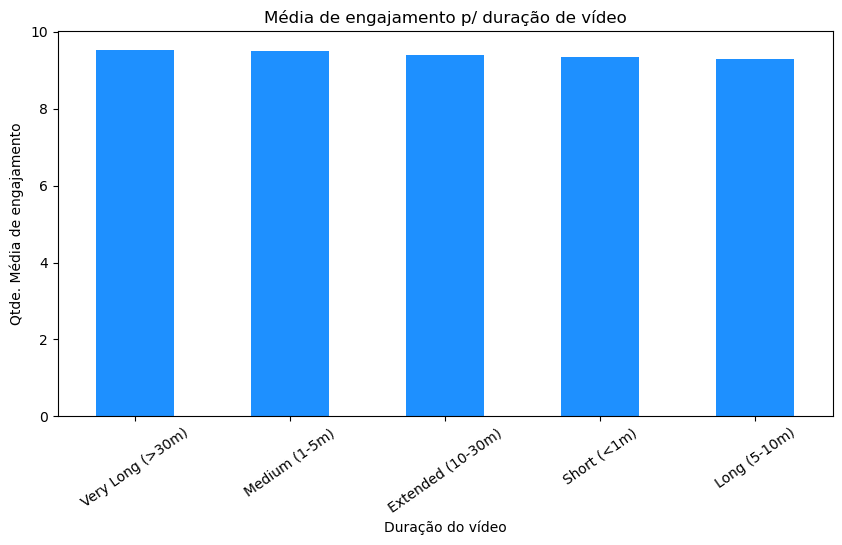

In [53]:
tam_video.plot(kind='bar', figsize=(10,5), color='dodgerblue')

#elaborando parametros do gráfico
plt.title('Média de engajamento p/ duração de vídeo')
plt.xlabel('Duração do vídeo')
plt.ylabel('Qtde. Média de engajamento')
plt.xticks(rotation=35)
plt.show()

Observa-se que a média de engajamento varia pouco entre as categorias de duração dos vídeos. Apesar dessa proximidade, os vídeos com duração "Very Long" (>30 minutos) apresentaram a maior taxa média de engajamento, indicando um desempenho ligeiramente superior em relação às demais durações.

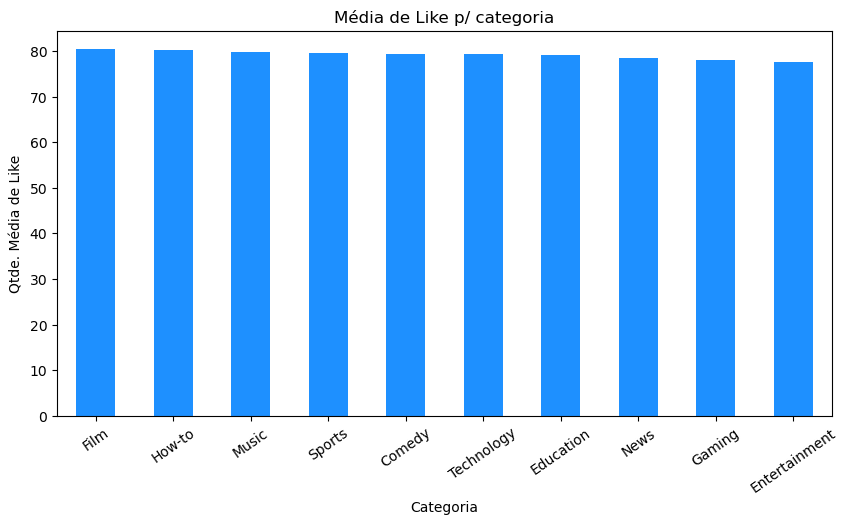

In [54]:
#criando o gráfico para visualizar os números
category_media.plot(kind='bar', figsize=(10,5), color='dodgerblue')

#elaborando parametros do gráfico
plt.title('Média de Like p/ categoria')
plt.xlabel('Categoria')
plt.ylabel('Qtde. Média de Like')
plt.xticks(rotation=35)
plt.show()

A média de likes por categoria apresentou pouca variação entre as categorias analisadas. Ainda assim, a categoria Film registrou a maior média de likes, indicando que, em média, seus vídeos recebem mais likes por publicação do que os das demais categorias. 

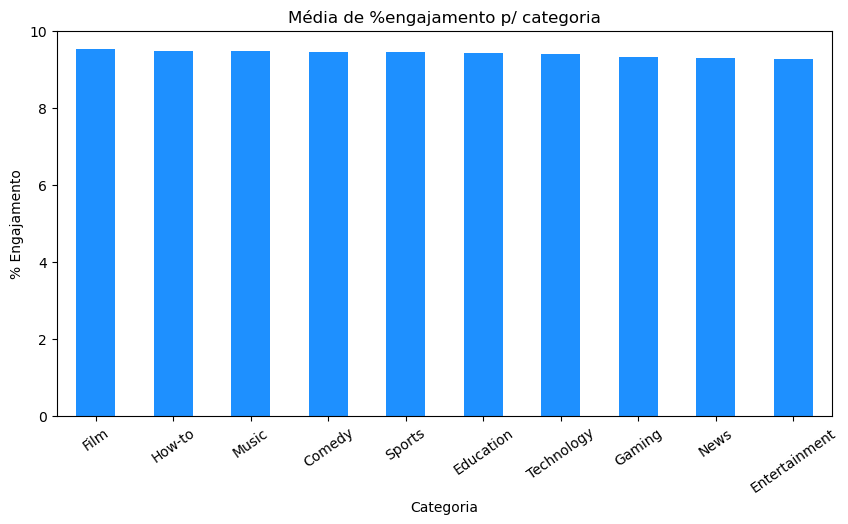

In [61]:
pec.plot(kind='bar', figsize=(10,5), color='dodgerblue')

#elaborando parametros do gráfico
plt.title('Média de %engajamento p/ categoria')
plt.xlabel('Categoria')
plt.ylabel('% Engajamento')
plt.xticks(rotation=35)
plt.show()

A média de engajamento por categoria teve uma variação semelhante a média de likes, porém com algumas diferenças. a categoria Film continua liderando como categoria com maior média de engajamento, ou seja, o engajamento por vídeo da categoria Film costuma ser mais elevado em relação as outras categorias.

In [59]:
pec = round(media_engaj_categoria * 100, 2)

In [60]:
pec

category
Film             9.54
How-to           9.50
Music            9.49
Comedy           9.46
Sports           9.46
Education        9.45
Technology       9.41
Gaming           9.33
News             9.32
Entertainment    9.27
Name: taxa_de_engajamento, dtype: float64

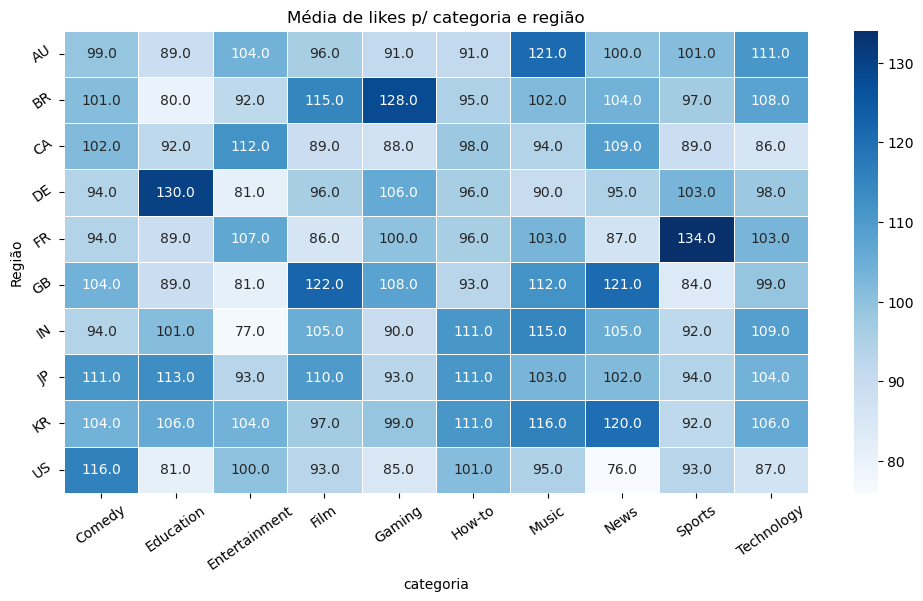

In [63]:
plt.figure(figsize=(12,6))

sns.heatmap(
    data=tb_df,
    annot=True,
    cmap='Blues',
    linewidths=0.5,
    fmt='.1f'
)

plt.title('Média de likes p/ categoria e região')
plt.xlabel('categoria')
plt.ylabel('Região')
plt.xticks(rotation = 35)
plt.yticks(rotation = 35)
plt.show()

A análise evidencia que a categoria com maior média de likes varia entre as regiões analisadas. Isso sugere que o desempenho dos vídeos não é uniforme globalmente e que fatores regionais podem estar associados às diferenças de interação observadas

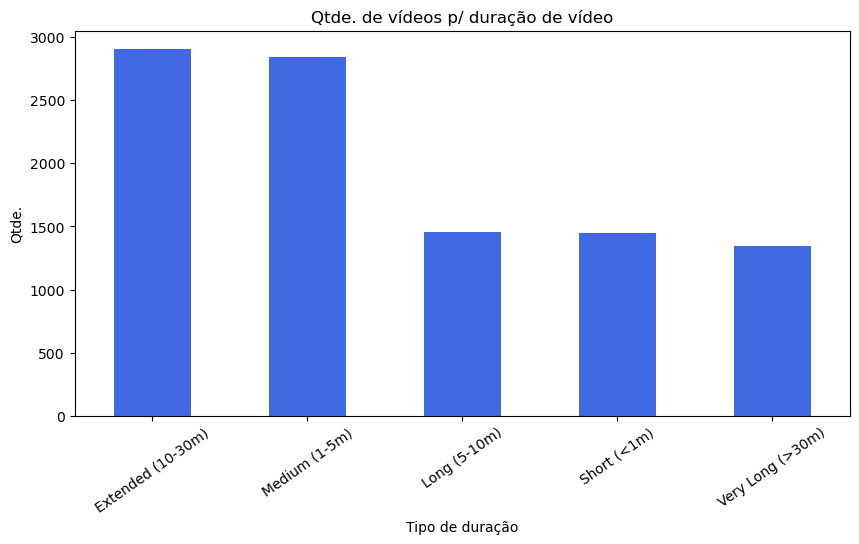

In [64]:
count_categoria_v.plot(kind='bar', figsize=(10,5), color='royalblue')

plt.title('Qtde. de vídeos p/ duração de vídeo')
plt.xlabel('Tipo de duração')
plt.xticks(rotation = 35)
plt.ylabel('Qtde.')
plt.show()

A quantidade de vídeos por duração apresentou variação significativa entre as categorias. As durações Extended (10–30 min) e Medium (1–5 min) concentraram o maior volume de vídeos da amostra. Entretanto, essa distribuição não foi acompanhada pela mesma ordem na média de likes, uma vez que a categoria Very Long (>30 min) apresentou a maior média de likes, mesmo possuindo uma quantidade consideravelmente menor de vídeos.

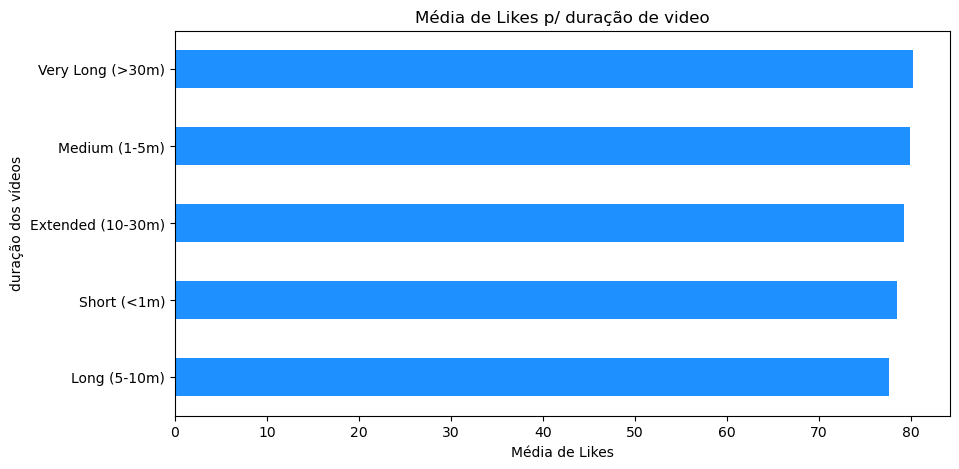

In [65]:
media_likes_c.plot(kind='barh', figsize=(10,5), color='dodgerblue')

plt.title('Média de Likes p/ duração de video')
plt.xlabel('Média de Likes')
plt.ylabel('duração dos vídeos')
plt.show()

A média de likes por duração apresentou pouca variação entre as categorias analisadas. Ainda assim, a categoria Very long(> 30m) registrou a maior média de likes, indicando que, em média, seus vídeos recebem mais likes por publicação do que os das demais categorias de duração.

In [66]:
filmxdrt = df[df['category'] == 'Film'].pivot_table(
    values='video_id',
    index = 'video_length_category',
    columns = 'category',
    aggfunc = 'count',
    fill_value = 0
).sort_values(ascending=False, by='Film')

In [67]:
filmxdrt

category,Film
video_length_category,
Medium (1-5m),302
Extended (10-30m),294
Long (5-10m),155
Very Long (>30m),131
Short (<1m),127


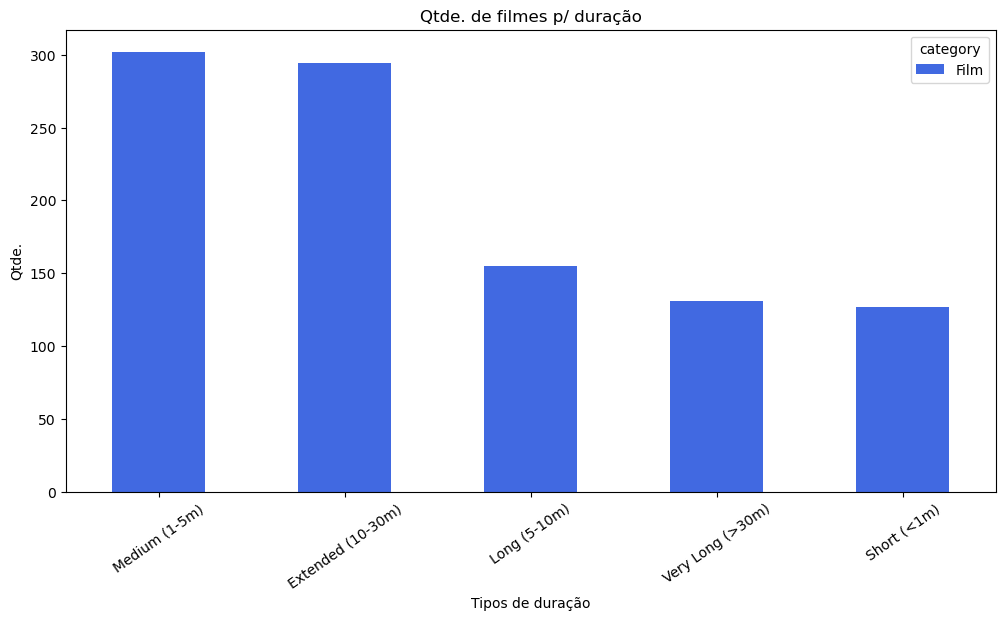

In [68]:
filmxdrt.plot(kind='bar', figsize=(12,6), color = 'royalblue')

plt.title('Qtde. de filmes p/ duração')
plt.xlabel('Tipos de duração')
plt.ylabel('Qtde.')
plt.xticks(rotation=35)
plt.show()

Entre os vídeos da categoria Film, as durações Medium (1–5 min) e Extended (10–30 min) concentram a maior quantidade de vídeos. Essas mesmas durações também apresentaram médias elevadas de likes na análise geral. Entretanto, quando o critério é taxa média de engajamento, os vídeos Very Long (>30 min) se destacam, apesar de representarem uma quantidade menor de publicações.

# Fim